In [1]:
import pandas as pd
import numpy as np

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Pandas version: 2.3.2
NumPy version: 1.26.4


In [2]:
import os
if os.path.exists('who_dataset.csv'):
    file_size = os.path.getsize('who_dataset.csv')
    print(f"File exists, size: {file_size} bytes")

    # READ first lines to see the form of the file.
    with open('who_dataset.csv', 'r', encoding='utf-8', errors='ignore') as f:
        lines = [f.readline() for _ in range(5)]


    print("\nFirst 5 lines (first 100 chars each):")
    #"for i, line in enumerate(lines)" could output the index i and the string of each line
    for i, line in enumerate(lines):
        print(f"Line {i}: {line[:100].strip()}")
else:
    print("ERROR: File 'who_dataset.csv' not found!")
    print("Files in current directory:", os.listdir('.')[:10])

print("\n" + "=" * 50)

File exists, size: 946135429 bytes

First 5 lines (first 100 chars each):
Line 0: ,ID,Sequence,Variant
Line 1: 0,EPI_ISL_9077130,--------------------------------------------------ttgtagatctgttctctaaacgaactttaaaa
Line 2: 1,EPI_ISL_4306496,----------------------------------------------------------------------------------
Line 3: 2,EPI_ISL_1208401,------------------------------------------------------agatctgttctctaaacgaactttaaaa
Line 4: 3,EPI_ISL_9073747,--------------------------------------------------ttgtagatctgttctctaaacgaactttaaaa



In [3]:
# Load the dataset
data_1_df = pd.read_csv('who_dataset.csv')
data_1_df.drop(['Unnamed: 0'],axis = 1, inplace = True)
display(data_1_df.head())
print(data_1_df.shape)

,ID,Sequence,Variant
0,EPI_ISL_9077130,----------------------------------------------...,Omicron
1,EPI_ISL_4306496,----------------------------------------------...,Delta
2,EPI_ISL_1208401,----------------------------------------------...,Beta
3,EPI_ISL_9073747,----------------------------------------------...,Omicron
4,EPI_ISL_2460597,----------------------------------------------...,Beta


(31624, 3)


In [4]:
# store all unique (not repeating) variant names
variants_unique = data_1_df['Variant'].unique()
print(variants_unique)

['Omicron' 'Delta' 'Beta' 'Alpha' 'Gamma']


In [5]:
# Dealing each variant
for variant in variants_unique:
    #Choose all same variants
    data = data_1_df[data_1_df['Variant'] == variant]
    print('Variant  = ', variant, 'and shape is ',data.shape)
    #generate the new csv file's name
    name = str(variant)+'_homoSequences.csv'
    #save all variant into a csv file with the name we set
    data.to_csv(name)

Variant  =  Omicron and shape is  (6375, 3)
Variant  =  Delta and shape is  (6387, 3)
Variant  =  Beta and shape is  (6213, 3)
Variant  =  Alpha and shape is  (6346, 3)
Variant  =  Gamma and shape is  (6303, 3)


### LOADING REFERENCE GENE

In [6]:
if os.path.exists('NC_045512_2_.txt'):
    file_size = os.path.getsize('NC_045512_2_.txt')
    print(f"File exists, size：{file_size} bytes")

    if file_size == 0:
        print("⚠️ File is empty！")
else:
    print("⚠️ File isn't exist！")

print("\n" + "="*50)

File exists, size：30332 bytes



In [7]:
# Reading the text file using open() function
with open('NC_045512_2_.txt', 'r') as file:
    content = file.read().replace('\n','')

# Display the content of the file
print(len(content))

29903


In [8]:
# count how many base pairs are same
def compute_similarity(sequence1, reference_sequence):
    # Initialize variables
    match_count = 0
    total_positions = len(sequence1)

    # Loop through each position in sequence1
    for i in range(total_positions):
        if sequence1[i] == reference_sequence[i]:
            match_count += 1  # Increment match count for each matching character

    # Compute the similarity score as a percentage
    similarity_score = (match_count / total_positions) * 100
    
    return round(similarity_score,2)

### BUILDING SCAFFOLD FOR OMICRON

In [9]:
# Load the dataset
data_1_ = pd.read_csv('Omicron_homoSequences.csv')
data_1_df_ = pd.DataFrame(data_1_)
data_1_df_.drop(['Unnamed: 0'],axis = 1, inplace = True)
# The line below equal with this:（IGNORE CHINESE PART）
#     for i in range(data_1_df_.shape[0]):
#       seq = data_1_.iloc[i]['Sequence']
#       ref = content.lower()
#       score = compute_similarity(seq, ref)
#       similarity_score.append(score)
similarity_score = [compute_similarity(data_1_.iloc[i]['Sequence'],content.lower()) for i in range(0,data_1_df_.shape[0])]
data_1_df_['Similarity_Score'] = similarity_score
display(data_1_df_.head())
print(data_1_df_.shape)

,ID,Sequence,Variant,Similarity_Score
0,EPI_ISL_9077130,----------------------------------------------...,Omicron,99.30
1,EPI_ISL_9073747,----------------------------------------------...,Omicron,99.21
2,EPI_ISL_9064446,----------------------------------------------...,Omicron,99.29
3,EPI_ISL_9067577,----------------------------------------------...,Omicron,95.95
4,EPI_ISL_9064721,----------------------------------------------...,Omicron,95.03


(6375, 4)


In [10]:
import re


# 1) Spike （1-based -> 0-based slice）
spike_start = 21563 - 1
spike_end   = 25384           # python slice
spike_len   = spike_end - spike_start


data_1_df_['SpikeSeq'] = data_1_df_['Sequence'].astype(str).str.lower().str.slice(spike_start, spike_end)


data_1_df_['SpikeGapCount'] = data_1_df_['SpikeSeq'].str.count('-')
data_1_df_['SpikeHasGap']   = data_1_df_['SpikeGapCount'] > 0
data_1_df_['SpikeGapRatio'] = data_1_df_['SpikeGapCount'] / spike_len

data_1_df_['SpikeGapRuns'] = data_1_df_['SpikeSeq'].str.findall(r'-+').apply(len)

data_1_df_['SpikeMaxGapRun'] = data_1_df_['SpikeSeq'].str.findall(r'-+').apply(lambda xs: max((len(x) for x in xs), default=0))


total = len(data_1_df_)
has_gap = int(data_1_df_['SpikeHasGap'].sum())
pct_has_gap = has_gap / total * 100

print(f"Total sequences: {total}")
print(f"Spike region (length={spike_len}) sequences with >=1 gap '-': {has_gap} ({pct_has_gap:.2f}%)")


gap_only = data_1_df_[data_1_df_['SpikeHasGap']]

print("\nSpike gap size (counts) summary among sequences WITH gaps:")
print(gap_only['SpikeGapCount'].describe())

print("\nSpike gap ratio summary among sequences WITH gaps:")
print((gap_only['SpikeGapRatio']*100).describe())

print("\nSpike gap run summary among sequences WITH gaps:")
print(gap_only[['SpikeGapRuns','SpikeMaxGapRun']].describe())


Total sequences: 6375
Spike region (length=3822) sequences with >=1 gap '-': 6152 (96.50%)

Spike gap size (counts) summary among sequences WITH gaps:
count    6152.000000
mean       20.102081
std       131.313333
min         3.000000
25%         9.000000
50%        18.000000
75%        18.000000
max      3822.000000
Name: SpikeGapCount, dtype: float64

Spike gap ratio summary among sequences WITH gaps:
count    6152.000000
mean        0.525957
std         3.435723
min         0.078493
25%         0.235479
50%         0.470958
75%         0.470958
max       100.000000
Name: SpikeGapRatio, dtype: float64

Spike gap run summary among sequences WITH gaps:
       SpikeGapRuns  SpikeMaxGapRun
count   6152.000000     6152.000000
mean       2.118336       14.958550
std        0.973211      131.037445
min        1.000000        3.000000
25%        1.000000        9.000000
50%        3.000000        9.000000
75%        3.000000        9.000000
max       12.000000     3822.000000


In [11]:
data_1_df_['Similarity_Score'].describe()

count    6375.000000
mean       97.491437
std         4.884807
min         5.890000
25%        97.340000
50%        98.780000
75%        99.250000
max        99.800000
Name: Similarity_Score, dtype: float64

In [12]:
x = []
for i in range(0,data_1_df_.shape[0]):
    x.append(len(data_1_df_.iloc[i]['Sequence']))
print(min(x), max(x))

29891 29891


In [13]:
# count how many non A/T/C/G exist in the sequence
def count_non_standard_chars(sequences, reference):
    # Define the set of standard characters
    standard_chars = {'a', 'c', 't', 'g'}
    
    # Initialize a list to store the frequency counts for each position
    non_standard_counts = [0] * len(reference)
    
    # Loop over each sequence in the list
    for seq in sequences:
        # Loop over each character in the sequence
        for i, char in enumerate(seq):
            if char.lower() not in standard_chars:  # Check if character is non-standard
                non_standard_counts[i] += 1
                
    return non_standard_counts

# # Example usage
# sequences = data_1_['Sequence'].to_list()#['actg-ccctgiga', 'acciiggttaa--cctgg', 'aaa--cctgigacctcga']
# reference = content.lower()#'actgccctgacttggcag'

# # Call the function
# non_standard_frequencies = count_non_standard_chars(sequences, reference)

# # Display the results
# print("Non-standard character frequencies by position:", non_standard_frequencies)


# count the number of mismatches, including
    # Real mutation (like A -> G)
    # uncertain(N)
    # Gap(-)
# Potential problem: here we serve '-''N' as mismatch, which are not exactly right.
# IGNORE THE CHINESE COMMENT BELOW
# 这里有个潜在的问题，把gap(-),(N)都当成mismatch（不匹配），后续也许会造成问题
def count_mismatches(sequences, reference):
    # Initialize a list to store the mismatch counts for each position
    mismatch_counts = [0] * len(reference)
    
    # Loop over each sequence in the list
    for seq in sequences:
        # Loop over each character in the sequence and compare to the reference sequence
        for i, char in enumerate(seq):
            if char != reference[i]:  # Check if the character does not match the reference
                mismatch_counts[i] += 1
    mismatch_counts_ratios = [round(i/len(sequences)*100,2) for i in mismatch_counts]
    return mismatch_counts, mismatch_counts_ratios

# # Example usage
# sequences = ['actg-ccctgiga', 'acciiggttaa--cctgg', 'aaa--cctgigacctcga']
# reference = 'actgccctgacttggcag'

# # Call the function
# mismatch_frequencies = count_mismatches(sequences, reference)

# # Display the results
# print("Mismatch frequencies by position:", mismatch_frequencies)

# At here we built a DataFram, each row corresponds to a position in the reference,and have information including:
    # Position: the position for describe
    # Reference: The base
    # Mismatch_Count: The count that not matche reference
    # Mismatch_Count_ratios: the ratio of that count

def construct_scaffold(sequences, reference, weight_mismatch=1, weight_non_standard=1):
    # Initialize the mismatch and non-standard counts
    mismatch_counts,mismatch_counts_ratios = count_mismatches(sequences, reference)
    #non_standard_counts = count_non_standard_chars(sequences, reference)
    
    # Initialize a dataframe to hold the scaffold
    scaffold = pd.DataFrame({
        'Position': range(1, len(reference) + 1),
        'Reference': list(reference),
        'Mismatch_Count': mismatch_counts,
        'Mismatch_Count_ratios': mismatch_counts_ratios
    })  
    
    return scaffold

# # Example usage
# sequences = ['actg-ccctgiga', 'acciiggttaa--cctgg', 'aaa--cctgigacctcga']
# reference = 'actgccctgacttggcag'

# # Construct the scaffold with default weights
# scaffold_df = construct_scaffold(sequences, reference)

# # Sort scaffold_df by the 'Weighted_Score' column in descending order
# scaffold_df_sorted = scaffold_df.sort_values(by='Weighted_Score', ascending=False)

# display(scaffold_df_sorted)


def bin_mismatch_counts(df, bin_size):
    # Calculate the number of bins needed
    num_bins = len(df) // bin_size
    
    # Create bins and calculate the mean mismatch count per bin

    binned_mismatch = df['Mismatch_Count'].groupby(np.arange(len(df)) // bin_size).mean()
    
    # Generate position labels for the bins (e.g., the middle position in each bin)

    binned_positions = df['Position'].groupby(np.arange(len(df)) // bin_size).mean()
    
    return binned_mismatch, binned_positions

In [14]:
# Example usage
sequences = data_1_['Sequence'].to_list()
reference = content.lower()

# Construct the scaffold with default weights
scaffold_df = construct_scaffold(sequences, reference)

# Sort scaffold_df by the 'Weighted_Score' column in descending order
scaffold_df_sorted = scaffold_df.sort_values(by='Mismatch_Count', ascending=False)
scaffold_df_sorted = scaffold_df_sorted[scaffold_df_sorted['Position']<= 29891]
display(scaffold_df_sorted)

# # Example: Bin size of 100
# bin_size = 500
# binned_mismatch, binned_positions = bin_mismatch_counts(scaffold_df, bin_size)

# # Plot the heatmap for binned data
# plt.figure(figsize=(12, 4))

# # Reshape the data for heatmap, it's 1 row of binned values
# sns.heatmap([binned_mismatch], cmap='YlGnBu', annot=False, cbar=True, xticklabels=binned_positions.astype(int))

# # Adjust the ticks
# plt.xticks(ticks=range(0, len(binned_positions), len(binned_positions) // 10), labels=binned_positions[::len(binned_positions) // 10].astype(int), rotation=45)

# plt.title(f'Mismatch_Count Heatmap (Binned, bin size={bin_size})')
# plt.xlabel('Position (Binned)')
# plt.ylabel('Mismatch Count')
# plt.show()


,Position,Reference,Mismatch_Count,Mismatch_Count_ratios
24468,24469,t,6372,99.95
23402,23403,a,6371,99.94
14407,14408,c,6370,99.92
25583,25584,c,6369,99.91
23524,23525,c,6368,99.89
...,...,...,...,...
13162,13163,a,13,0.20
13164,13165,a,13,0.20
13165,13166,c,13,0.20
15704,15705,g,13,0.20


In [15]:
scaffold_df_sorted_ratioThreshold = scaffold_df_sorted[scaffold_df_sorted['Mismatch_Count_ratios']>=50]
scaffold_df_sorted_ratioThreshold

,Position,Reference,Mismatch_Count,Mismatch_Count_ratios
24468,24469,t,6372,99.95
23402,23403,a,6371,99.94
14407,14408,c,6370,99.92
25583,25584,c,6369,99.91
23524,23525,c,6368,99.89
...,...,...,...,...
29830,29831,c,3446,54.05
29829,29830,g,3432,53.84
29828,29829,t,3426,53.74
29827,29828,g,3391,53.19


,Position,Reference,Mismatch_Count,Mismatch_Count_ratios,ORF
24468,24469,t,6372,99.95,S
23402,23403,a,6371,99.94,S
14407,14408,c,6370,99.92,ORF1ab
25583,25584,c,6369,99.91,ORF3a
23524,23525,c,6368,99.89,S
...,...,...,...,...,...
29830,29831,c,3446,54.05,Non-coding Region
29829,29830,g,3432,53.84,Non-coding Region
29828,29829,t,3426,53.74,Non-coding Region
29827,29828,g,3391,53.19,Non-coding Region



Mismatch Counts Summed by ORF Region:
                 ORF  Mismatch_Count
0                  E            6361
1                  M           16333
2                  N           82155
3  Non-coding Region          341307
4             ORF1ab          382058
5              ORF3a            6369
6               ORF6            6337
7              ORF7b            6348
8                  S          243325

ORF Region Frequency:
ORF
ORF1ab               74
Non-coding Region    65
S                    49
N                    13
M                     3
ORF3a                 1
E                     1
ORF7b                 1
ORF6                  1
Name: count, dtype: int64


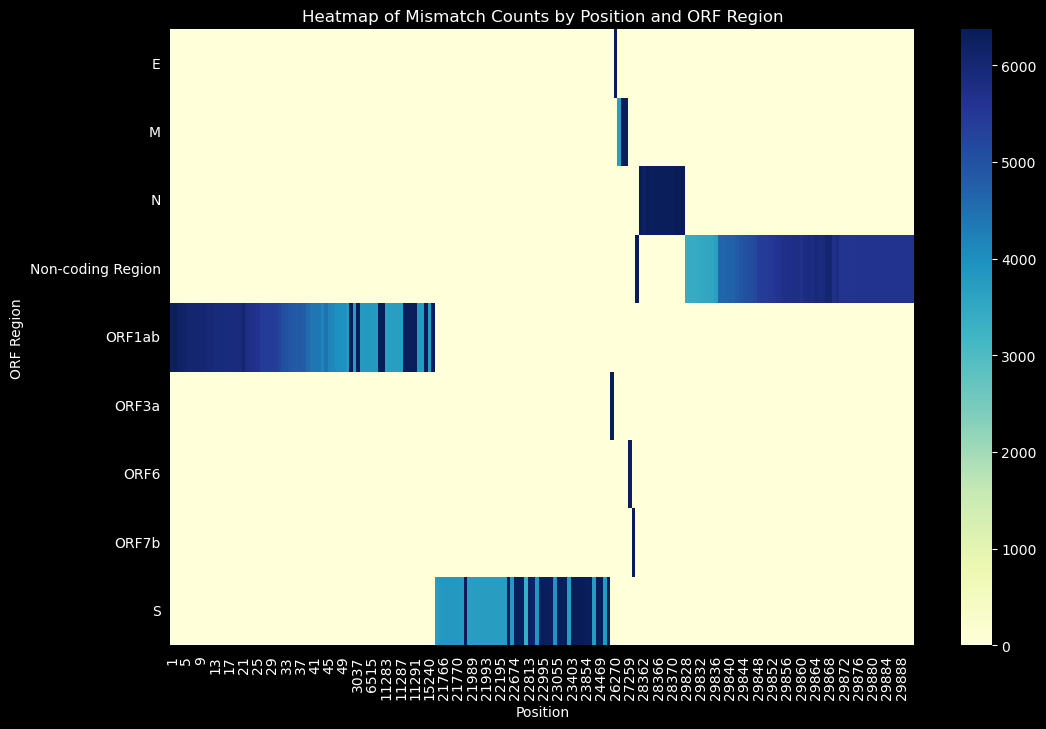

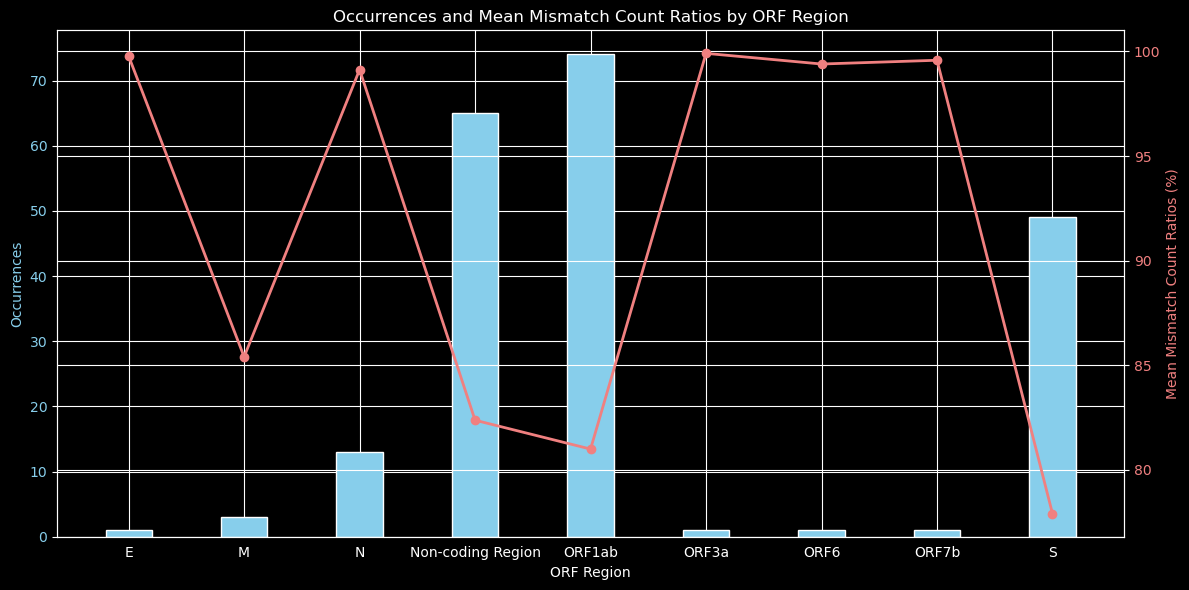

In [16]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

#See the cell below, we selected positions with mismatch_ratio > X and sorted it
df =  scaffold_df_sorted_ratioThreshold.copy()

# Define the ORF regions
# The 's' is the SPIKE position
orf_regions = [
    {'ORF': 'ORF1ab', 'Start': 1, 'End': 21290},
    {'ORF': 'S', 'Start': 21563, 'End': 25384},
    {'ORF': 'ORF3a', 'Start': 25393, 'End': 26220},
    {'ORF': 'E', 'Start': 26245, 'End': 26472},
    {'ORF': 'M', 'Start': 26523, 'End': 27191},
    {'ORF': 'ORF6', 'Start': 27232, 'End': 27387},
    {'ORF': 'ORF7a', 'Start': 27393, 'End': 27759},
    {'ORF': 'ORF7b', 'Start': 27755, 'End': 27887},
    {'ORF': 'ORF8', 'Start': 27893, 'End': 28259},
    {'ORF': 'N', 'Start': 28274, 'End': 29533},
    {'ORF': 'ORF10', 'Start': 29558, 'End': 29674}
]

# Convert orf_regions to a DataFrame for easier manipulation

orf_df = pd.DataFrame(orf_regions)

# Function to assign ORF region to each position

def assign_orf(position):
    for idx, row in orf_df.iterrows():
        if row['Start'] <= position <= row['End']:
            return row['ORF']
    return 'Non-coding Region'  # Positions that don't fall into any ORF

# Apply the function to the 'Position' column to create a new 'ORF' column
df['ORF'] = df['Position'].apply(assign_orf)

# Display the updated DataFrame
display(df)

# Now you can group the DataFrame based on the 'ORF' column
grouped_df = df.groupby('ORF')

# For example, sum the mismatch counts per ORF region
orf_mismatch_sums = grouped_df['Mismatch_Count'].sum().reset_index()

print("\nMismatch Counts Summed by ORF Region:")
print(orf_mismatch_sums)

print("\nORF Region Frequency:")
print(df['ORF'].value_counts())

# Pivot the DataFrame for heatmap
pivot_df = df.pivot_table(values='Mismatch_Count', index='ORF', columns='Position', fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, cmap='YlGnBu')
plt.title('Heatmap of Mismatch Counts by Position and ORF Region')
plt.xlabel('Position')
plt.ylabel('ORF Region')
plt.show()

# Group by ORF_region to get occurrences and mean mismatch ratios
summary_df = df.groupby('ORF').agg(
    Occurrences=('Position', 'count'),
    Mean_Mismatch_Count_Ratios=('Mismatch_Count_ratios', 'mean')
).reset_index()

# Display the result
summary_df['Mean_Mismatch_Count_Ratios'] = summary_df['Mean_Mismatch_Count_Ratios'].round(2)  # Round the ratios for clarity
#display(summary_df)

#Create the figure and axis objects
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the Occurrences on the left y-axis
ax1.bar(summary_df['ORF'], summary_df['Occurrences'], color='skyblue', label='Occurrences', width=0.4)
ax1.set_xlabel('ORF Region')
ax1.set_ylabel('Occurrences', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Create a second y-axis for Mean Mismatch Count Ratios
ax2 = ax1.twinx()
ax2.plot(summary_df['ORF'], summary_df['Mean_Mismatch_Count_Ratios'], color='lightcoral', marker='o', label='Mean Mismatch Count Ratios', linewidth=2)
ax2.set_ylabel('Mean Mismatch Count Ratios (%)', color='lightcoral')
ax2.tick_params(axis='y', labelcolor='lightcoral')

# Add the title
plt.title('Occurrences and Mean Mismatch Count Ratios by ORF Region')

# Rotate x-axis labels for clarity
plt.xticks(rotation=45, ha='right')

# Show the plot
plt.tight_layout()
plt.show()

In [17]:
# [scaffold_df_sorted_ratioThreshold['ORF']=='S']： we only care about Spike area here
# ['Position']: We use this column
# .to_list() We convert panda series to normal python list
# Notion: The scaffold_df_sorted_ratioThreshold was under filtered, it isn't all mismatch positions, it only contains >50 mismatches


len(df
        [df['ORF']=='S']
        ['Position']
        .to_list()
    )

49

In [18]:
#convert 'scaffold_df_sorted_ratioThreshold''s 'spike area''s position into numpy array for output
#Here we print all high mismatch position

s_region_mismatch = np.array(df[df['ORF']=='S']['Position'].to_list())
print(s_region_mismatch)
print(s_region_mismatch.shape)

[24469 23403 23525 24424 23599 23948 23604 22578 21987 25000 23063 23055
 22679 23075 22674 23854 23013 22995 22686 22992 23040 22813 22882 23048
 22898 21768 21767 22673 21766 21770 21769 21765 21846 23202 24130 24503
 21762 21988 21990 21993 21989 21992 21991 22194 22196 21994 21995 22195
 22786]
(49,)


In [19]:
def compare_and_format_with_ansi(sequence2, reference_sequence):
    formatted_sequence = []

    # ANSI escape codes for bold red text and reset
    bold_red_start = "\033[1;31m"  # Bold and red
    reset = "\033[0m"  # Reset formatting

    # Iterate over each position in the sequences
    for i in range(len(sequence2)):
        char2 = sequence2[i]
        ref_char = reference_sequence[i]

        if char2 != ref_char:
            if char2 == '-':
                # Color mismatch with '-' in bolded red
                formatted_sequence.append(f'{bold_red_start}{char2}{reset}')
            elif char2 not in ['a', 'c', 't', 'g']:
                # Replace invalid character with 'i' and color bolded red
                formatted_sequence.append(f'{bold_red_start}i{reset}')
            else:
                # Keep mismatched character as is (no coloring if it's a valid base)
                formatted_sequence.append(char2)
        else:
            # If the characters match, add the character as is
            formatted_sequence.append(char2)

    # Join the formatted characters into a string and return it
    return ''.join(formatted_sequence)

# Example usage
reference_sequence = content.lower()[21563-1: 25384]
sequence2 = data_1_df_.iloc[0]['Sequence'][21563-1: 25384]

# Call the function and print the result
formatted_sequence = compare_and_format_with_ansi(sequence2, reference_sequence)
print(formatted_sequence)


atgtttgtttttcttgttttattgccactagtctctagtcagtgtgttaatcttacaaccagaactcaattaccccctgcatacactaattctttcacacgtggtgtttattaccctgacaaagttttcagatcctcagttttacattcaactcaggacttgttcttacctttcttttccaatgttacttggttccatgtta------tctctgggaccaatggtactaagaggtttgataaccctgtcctaccatttaatgatggtgtttattttgcttccattgagaagtctaacataataagaggctggatttttggtactactttagattcgaagacccagtccctacttattgttaataacgctactaatgttgttattaaagtctgtgaatttcaattttgtaatgatccatttttgg---------accacaaaaacaacaaaagttggatggaaagtgagttcagagtttattctagtgcgaataattgcacttttgaatatgtctctcagccttttcttatggaccttgaaggaaaacagggtaatttcaaaaatcttagggaatttgtgtttaagaatattgatggttattttaaaatatattctaagcacacgcctatta---tagtgcgtgatctccctcagggtttttcggctttagaaccattggtagatttgccaataggtattaacatcactaggtttcaaactttacttgctttacatagaagttatttgactcctggtgattcttcttcaggttggacagctggtgctgcagcttattatgtgggttatcttcaacctaggacttttctattaaaatataatgaaaatggaaccattacagatgctgtagactgtgcacttgaccctctctcagaaacaaagtgtacgttgaaatccttcactgtagaaaaaggaatctatcaaacttctaactttagagtccaaccaacagaatctattgttagatttcctaatattacaa

In [20]:
# Example usage
reference_sequence = content.lower()[21563-1: 25384]
sequence2 = data_1_df_.iloc[80]['Sequence'][21563-1: 25384]

# Call the function and print the result
formatted_sequence = compare_and_format_with_ansi(sequence2, reference_sequence)
print(formatted_sequence)

atgtttgtttttcttgttttattgccactagtctctagtcagtgtgttaatcttataaccagaactcaat---------catacactaattctttcacacgtggtgtttattaccctgacaaagttttcagatcctcagttttacattcaactcaggacttgttcttacctttcttttccaatgttacttggttccatgctatacatgtctctgggaccaatggtactaagaggtttgataaccctgtcctaccatttaatgatggtgtttattttgcttccactgagaagtctaacataataagaggctggatttttggtactactttagattcgaagacccagtccctacttattgttaataacgctactaatgttgttattaaagtctgtgaatttcaattttgtaatgatccatttttggatgtttattaccacaaaaacaacaaaagttggatggaaagtgagttcagagtttattctagtgcgaataattgcacttttgaatatgtctctcagccttttcttatggaccttgaaggaaaacagggtaatttcaaaaatcttagggaatttgtgtttaagaatattgatggttattttaaaatatattctaagcacacgcctattaatttagggcgtgatctccctcagggtttttcggctttagaaccattggtagatttgccaataggtattaacatcactaggtttcaaactttacttgctttacatagaagttatttgactcctggtgattcttcttcaggttggacagctggtgctgcagcttattatgtgggttatcttcaacctaggacttttctattaaaatataatgaaaatggaaccattacagatgctgtagactgtgcacttgaccctctctcagaaacaaagtgtacgttgaaatccttcactgtagaaaaaggaatctatcaaacttctaactttagagtccaaccaacagaatctattgttagatttcctaatattacaa

In [21]:
sequence2 = data_1_df_.iloc[100]['Sequence'][21563-1: 25384]
sequence2

'atgtttgtttttcttgttttattgccactagtctctagtcagtgtgttaatcttacaaccagaactcaattaccccctgcatacactaattctttcacacgtggtgtttattaccctgacaaagttttcagatcctcagttttacattcaactcaggacttgttcttacctttcttttccaatgttacttggttccatgtta------tctctgggaccaatggtactaagaggtttgataaccctgtcctaccatttaatgatggtgtttattttgcttccattgagaagtctaacataataagaggctggatttttggtactactttagattcnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnaagtctgtgaatttcaattttgtaatgatccatttttgg---------accacaaaaacaacaaaagttggatggaaagtgagttcagagtttattctagtgcgaataattgcacttttgaatatgtctctcagccttttcttatggaccttgaaggaaaacagggtaatttcaaaaatcttagggaatttgtgtttaagaatattgatggttattttaaaatatattctaagcacacgcctatta---tagtgcgtgatctccctcagggtttttcggctttagaaccattggtagatttgccaataggtattaacatcactaggtttcaaactttacttgctttacnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnnttcaacctaggacttttctattaaaatataatgaaaatggaaccattacagatgctgtagactgtgcacttgaccctctctcagaaacaaagtgtacgttgaaatccttcactgtagaaaaaggaatctatcaaacttctaactttagagtccaaccaacagaatctattgttagatttcctaatattaca

### Second Approach

In [22]:
len(data_1_df_['Sequence'].to_list())

6375

In [23]:
import numpy as np
from tqdm import tqdm

# Key algorithm: Count the occurrence of A/T/C/G/-/i and calculate their ratio
def compute_nucleotide_frequencies(sequences, ref_seq):
    num_sequences = len(sequences)
    seq_length = 29891  # Length of each sequence to consider
    nucleotides = ['a', 'c', 't', 'g', '-', 'i']
    
    # Initialize the output array of shape (29891, 6) for each nucleotide frequency count
    frequency_array = np.zeros((seq_length, len(nucleotides)), dtype=int)

    # Iterate through each position in the sequences (up to 29891)
    for pos in tqdm(range(seq_length)):
        # For each position, count the occurrences of a, c, t, g, -, i
        counts = {nuc: 0 for nuc in nucleotides}
        
        for seq in sequences:
            nuc = seq[pos] if pos < len(seq) else '-'
            if nuc in ['a', 'c', 't', 'g', '-']:
                counts[nuc] += 1
            else:
                counts['i'] += 1

        # Store the frequencies in the array
        frequency_array[pos] = [(counts['a']/len(sequences))*100, (counts['c']/len(sequences))*100, (counts['t']/len(sequences))*100, 
                                (counts['g']/len(sequences))*100, (counts['-']/len(sequences))*100, (counts['i']/len(sequences))*100]

    return frequency_array

#Example Usage:
sequences = data_1_df_['Sequence'].to_list()#[list_of_sequences]  # List of sequences with each of length 29891
ref_seq = content.lower()#"reference_sequence_of_length_29903"
frequencies = compute_nucleotide_frequencies(sequences, ref_seq)
print(frequencies.shape)  # Output will be (29891, 6)


100%|██████████| 29891/29891 [00:20<00:00, 1455.39it/s]

(29891, 6)


In [24]:
def print_colored_scaffold(scaffold):
    # ANSI escape codes for formatting
    bold_black = '\033[1;30m'
    bold_red = '\033[1;31m'
    reset = '\033[0m'
    
    # Iterate over each character in the scaffold
    for nucleotide in scaffold:
        if nucleotide in ['a', 'c', 't', 'g']:
            # Print a, c, t, g in bold green
            print(f"{bold_black}{nucleotide}{reset}", end="")
        elif nucleotide in ['-', 'i']:
            # Print -, i in bold red
            print(f"{bold_red}{nucleotide}{reset}", end="")
        else:
            # Print any other character without coloring (shouldn't occur based on input spec)
            print(nucleotide, end="")
    
    # Add a newline at the end
    print()

# Example Usage:
# Assuming 'scaffold' is the string generated from the earlier function
# scaffold = "a-tgca-i"
# print_colored_scaffold(scaffold)


In [25]:
import numpy as np

def generate_scaffold(frequency_array):
    nucleotides = ['a', 'c', 't', 'g', '-', 'i']
    scaffold = []

    # Iterate over each position's frequency array
    for frequencies in frequency_array:
        # Find the index of the max frequency using argmax
        max_index = np.argmax(frequencies)
        # Append the corresponding nucleotide to the scaffold
        scaffold.append(nucleotides[max_index])
    
    # Join the scaffold list into a string
    return ''.join(scaffold)

# Example Usage:
#Assuming frequencies is the result of compute_nucleotide_frequencies
scaffold = generate_scaffold(frequencies)
print_colored_scaffold(scaffold)


--------------------------------------------------ttgtagatctgttctctaaacgaactttaaaatctgtgtggctgtcactcggctgcatgcttagtgcactcacgcagtataattaataactaattactgtcgttgacaggacacgagtaactcgtctatcttctgcaggctgcttacggtttcgtccgtgttgcagccgatcatcagcacatctaggttttgtccgggtgtgaccgaaaggtaagatggagagccttgtccctggtttcaacgagaaaacacacgtccaactcagtttgcctgttttacaggttcgcgacgtgctcgtacgtggctttggagactccgtggaggaggtcttatcagaggcacgtcaacatcttaaagatggcacttgtggcttagtagaagttgaaaaaggcgttttgcctcaacttgaacagccctatgtgttcatcaaacgttcggatgctcgaactgcacctcatggtcatgttatggttgagctggtagcagaactcgaaggcattcagtacggtcgtagtggtgagacacttggtgtccttgtccctcatgtgggcgaaataccagtggcttaccgcaaggttcttcttcgtaagaacggtaataaaggagctggtggccatagttacggcgccgatctaaagtcatttgacttaggcgacgagcttggcactgatccttatgaagattttcaagaaaactggaacactaaacatagcagtggtgttacccgtgaactcatgcgtgagcttaacggaggggcatacactcgctatgtcgataacaacttctgtggccctgatggctaccctcttgagtgcattaaagaccttctagcacgtgctggtaaagcttcatgcactttgtccgaacaactggactttattgacactaagaggggtgtatactgctgccgtgaacatgagcatgaaattgcttggtacacggaacgttct

In [26]:
import numpy as np

def generate_scaffold_with_threshold(frequency_array, threshold):
    nucleotides = ['a', 'c', 't', 'g', '-', 'i']
    scaffold = []

    # Iterate over each position's frequency array
    for frequencies in frequency_array:
        # Check if the last two frequencies ('-' and 'i') are above the threshold
        if frequencies[-2] >= threshold or frequencies[-1] >= threshold:
            # Pick the max between '-' and 'i'
            max_index = np.argmax(frequencies[-2:]) + len(frequencies) - 2
        else:
            # Pick the max from the entire frequency array
            max_index = np.argmax(frequencies)
        
        # Append the corresponding nucleotide to the scaffold
        scaffold.append(nucleotides[max_index])
    
    # Join the scaffold list into a string renwu
    return ''.join(scaffold)

# Example Usage:
# Assuming frequencies is the result of compute_nucleotide_frequencies
threshold = 15  # Define the threshold for '-' and 'i' (this tells that at least threshold% of our data at the specified nucleotide postision is - or i)
scaffold = generate_scaffold_with_threshold(frequencies, threshold)
print_colored_scaffold(scaffold)


------------------------------------------------------agatctgttctctaaacgaactttaaaatctgtgtggctgtcactcggctgcatgcttagtgcactcacgcagtataattaataactaattactgtcgttgacaggacacgagtaactcgtctatcttctgcaggctgcttacggtttcgtccgtgttgcagccgatcatcagcacatctaggttttgtccgggtgtgaccgaaaggtaagatggagagccttgtccctggtttcaacgagaaaacacacgtccaactcagtttgcctgttttacaggttcgcgacgtgctcgtacgtggctttggagactccgtggaggaggtcttatcagaggcacgtcaacatcttaaagatggcacttgtggcttagtagaagttgaaaaaggcgttttgcctcaacttgaacagccctatgtgttcatcaaacgttcggatgctcgaactgcacctcatggtcatgttatggttgagctggtagcagaactcgaaggcattcagtacggtcgtagtggtgagacacttggtgtccttgtccctcatgtgggcgaaataccagtggcttaccgcaaggttcttcttcgtaagaacggtaataaaggagctggtggccatagttacggcgccgatctaaagtcatttgacttaggcgacgagcttggcactgatccttatgaagattttcaagaaaactggaacactaaacatagcagtggtgttacccgtgaactcatgcgtgagcttaacggaggggcatacactcgctatgtcgataacaacttctgtggccctgatggctaccctcttgagtgcattaaagaccttctagcacgtgctggtaaagcttcatgcactttgtccgaacaactggactttattgacactaagaggggtgtatactgctgccgtgaacatgagcatgaaattgcttggtacacggaacgttct

In [27]:

SPIKE_START = 21563
SPIKE_END   = 25384

def gap_regions_and_len(s: str, gap_chars=set("-")):
    regions = []
    in_gap = False
    start = None
    for i, ch in enumerate(s):
        if ch in gap_chars:
            if not in_gap:
                in_gap = True
                start = i
        else:
            if in_gap:
                regions.append((start, i))
                in_gap = False
    if in_gap:
        regions.append((start, len(s)))

    lengths = [e - b for b, e in regions]
    return {
        "num_regions": len(regions),
        "total_len": sum(lengths),
        "max_run": max(lengths) if lengths else 0,
        "regions": regions
    }

# 如果你已经有 scaffold（全长）
scaffold_spike = scaffold[SPIKE_START-1:SPIKE_END]

gap_stats = gap_regions_and_len(scaffold_spike)

print("=== FINAL SCAFFOLD SPIKE GAP STATS ===")
print("Num gap regions:", gap_stats["num_regions"])
print("Total gap length:", gap_stats["total_len"])
print("Max gap run:", gap_stats["max_run"])


=== FINAL SCAFFOLD SPIKE GAP STATS ===
Num gap regions: 4
Total gap length: 27
Max gap run: 9


In [29]:
sequence3 = scaffold[21563-1: 25384]
print_colored_scaffold(sequence3)

atgtttgtttttcttgttttattgccactagtctctagtcagtgtgttaatcttacaaccagaactcaat---------catacactaattctttcacacgtggtgtttattaccctgacaaagttttcagatcctcagttttacattcaactcaggacttgttcttacctttcttttccaatgttacttggttccatgtta------tctctgggaccaatggtactaagaggtttgataaccctgtcctaccatttaatgatggtgtttattttgcttccattgagaagtctaacataataagaggctggatttttggtactactttagattcgaagacccagtccctacttattgttaataacgctactaatgttgttattaaagtctgtgaatttcaattttgtaatgatccatttttgg---------accacaaaaacaacaaaagttggatggaaagtgagttcagagtttattctagtgcgaataattgcacttttgaatatgtctctcagccttttcttatggaccttgaaggaaaacagggtaatttcaaaaatcttagggaatttgtgtttaagaatattgatggttattttaaaatatattctaagcacacgcctatta---tagtgcgtgatctccctcagggtttttcggctttagaaccattggtagatttgccaataggtattaacatcactaggtttcaaactttacttgctttacatagaagttatttgactcctggtgattcttcttcaggttggacagctggtgctgcagcttattatgtgggttatcttcaacctaggacttttctattaaaatataatgaaaatggaaccattacagatgctgtagactgtgcacttgaccctctctcagaaacaaagtgtacgttgaaatccttcactgtagaaaaaggaatctatcaaacttctaactttagagtccaaccaacagaatctattgttagatttcctaatattacaa

### New Approach

In [30]:
import pandas as pd

SPIKE_START = 21563  # 1-based inclusive
SPIKE_END   = 25384  # 1-based inclusive

def spike_slice(seq: str) -> str:
    # convert 1-based inclusive to python slice
    return seq[SPIKE_START-1:SPIKE_END]

def gap_regions_and_len(s: str, gap_chars=set("-")):
    """Return (num_regions, total_gap_len, max_run_len, regions_list)."""
    regions = []
    in_gap = False
    start = None
    for i, ch in enumerate(s):
        if ch in gap_chars:
            if not in_gap:
                in_gap = True
                start = i
        else:
            if in_gap:
                regions.append((start, i))
                in_gap = False
                start = None
    if in_gap:
        regions.append((start, len(s)))

    lengths = [e - b for b, e in regions]
    total_len = sum(lengths)
    max_run = max(lengths) if lengths else 0
    return len(regions), total_len, max_run, regions

def add_gap_stats(df: pd.DataFrame, seq_col="Sequence", gap_chars=set("-"), prefix="Gap"):
    spike = df[seq_col].astype(str).str.lower().apply(spike_slice)
    stats = spike.apply(lambda s: gap_regions_and_len(s, gap_chars=gap_chars))
    df_out = df.copy()
    df_out[f"{prefix}_Spike_NumRegions"] = stats.apply(lambda x: x[0])
    df_out[f"{prefix}_Spike_TotalLen"]   = stats.apply(lambda x: x[1])
    df_out[f"{prefix}_Spike_MaxRun"]     = stats.apply(lambda x: x[2])
    return df_out

# === run on Omicron subset ===
data_1_df_ = pd.read_csv("Omicron_homoSequences.csv")

# 口径1：只算 '-'
df_dash = add_gap_stats(data_1_df_, seq_col="Sequence", gap_chars=set("-"), prefix="DASH")

# 口径2：算 '-' 和 'i'
df_dashi = add_gap_stats(data_1_df_, seq_col="Sequence", gap_chars=set(["-","i"]), prefix="DASHI")

# 汇总：全体 gap regions 与 gap total length
summary = pd.DataFrame({
    "metric": [
        "Total gap regions (only '-')",
        "Total gap length  (only '-')",
        "Total gap regions ('-' + 'i')",
        "Total gap length  ('-' + 'i')",
        "Num sequences"
    ],
    "value": [
        int(df_dash["DASH_Spike_NumRegions"].sum()),
        int(df_dash["DASH_Spike_TotalLen"].sum()),
        int(df_dashi["DASHI_Spike_NumRegions"].sum()),
        int(df_dashi["DASHI_Spike_TotalLen"].sum()),
        int(len(data_1_df_))
    ]
})

summary


,metric,value
0,Total gap regions (only '-'),13032
1,Total gap length (only '-'),123668
2,Total gap regions ('-' + 'i'),13032
3,Total gap length ('-' + 'i'),123668
4,Num sequences,6375


In [31]:
import pandas as pd
from collections import Counter


df = pd.read_csv("Omicron_homoSequences.csv")
seqs = df["Sequence"].astype(str).str.lower().tolist()


cnt = Counter()
for s in seqs:
    cnt.update(s)


total = sum(cnt.values())
print("Total characters:", total)
print("Unique characters:", len(cnt))
print("Top 30 chars:")
for ch, c in cnt.most_common(30):
    print(f"{repr(ch)}\t{c}\t{c/total:.6%}")


acgt = set("acgt")
others = [(ch, c) for ch, c in cnt.items() if ch not in acgt]
others_sorted = sorted(others, key=lambda x: -x[1])
print("\nNon-ACGT chars:")
for ch, c in others_sorted:
    print(f"{repr(ch)}\t{c}")


Total characters: 190555125
Unique characters: 15
Top 30 chars:
't'	59914948	31.442318%
'a'	55650730	29.204531%
'g'	36527375	19.168928%
'c'	34069754	17.879212%
'n'	2904307	1.524130%
'-'	1485700	0.779669%
'y'	778	0.000408%
'r'	540	0.000283%
'k'	328	0.000172%
'm'	256	0.000134%
's'	218	0.000114%
'w'	184	0.000097%
'd'	5	0.000003%
'h'	1	0.000001%
'v'	1	0.000001%

Non-ACGT chars:
'n'	2904307
'-'	1485700
'y'	778
'r'	540
'k'	328
'm'	256
's'	218
'w'	184
'd'	5
'h'	1
'v'	1


In [32]:
IUPAC = set(list("ryswkmbdhvn"))  # IUPAC
ACGT = set("acgt")

non_acgt_chars = {ch for ch in cnt.keys() if ch not in ACGT}
print("Non-ACGT unique chars:", sorted(non_acgt_chars))

print("\nBreakdown:")
print("IUPAC chars:", sorted(non_acgt_chars & IUPAC))
print("Non-IUPAC chars:", sorted(non_acgt_chars - IUPAC))


Non-ACGT unique chars: ['-', 'd', 'h', 'k', 'm', 'n', 'r', 's', 'v', 'w', 'y']

Breakdown:
IUPAC chars: ['d', 'h', 'k', 'm', 'n', 'r', 's', 'v', 'w', 'y']
Non-IUPAC chars: ['-']


In [33]:
import numpy as np

L = len(seqs[0])
assert all(len(s) == L for s in seqs), "Not all sequences have same length!"

ACGT = set("acgt")

# 计算每个位点 非ACGT 的比例
non_acgt_rate = np.zeros(L, dtype=float)
for i in range(L):
    c = sum(1 for s in seqs if s[i] not in ACGT)
    non_acgt_rate[i] = c / len(seqs)

# 输出 top positions
topk = 50
idx = np.argsort(-non_acgt_rate)[:topk]
print(f"Top {topk} positions by non-ACGT rate:")
for i in idx:
    print(i+1, f"{non_acgt_rate[i]*100:.2f}%")  # +1 用 1-based 坐标


Top 50 positions by non-ACGT rate:
11288 99.18%
28366 99.14%
28367 99.09%
28368 99.07%
28365 99.03%
28369 99.01%
11289 99.00%
28370 98.78%
11291 98.57%
11290 98.53%
2 98.49%
28364 98.49%
28363 98.45%
1 98.12%
28362 97.47%
3 96.85%
4 96.38%
5 95.59%
6 95.25%
7 95.03%
8 94.65%
9 94.35%
10 94.13%
11 93.66%
12 93.38%
29867 92.94%
13 92.82%
29868 92.69%
14 92.67%
15 92.58%
16 92.35%
17 92.19%
18 92.00%
19 91.98%
20 91.92%
21 91.86%
29866 91.81%
29865 91.72%
29864 91.33%
29863 91.18%
29859 90.62%
29858 90.51%
22 90.48%
29857 90.16%
29856 90.01%
23 89.73%
29855 89.73%
29862 89.65%
29869 89.57%
29861 89.41%


In [34]:
from collections import Counter

top_positions = idx[:20]
for i in top_positions:
    cc = Counter(s[i] for s in seqs)
    total = sum(cc.values())

    top = cc.most_common(10)
    print(f"\nPosition {i+1} (non-ACGT={non_acgt_rate[i]*100:.2f}%):")
    for ch, c in top:
        print(f"  {repr(ch)}: {c} ({c/total:.2%})")



Position 11288 (non-ACGT=99.18%):
  '-': 6148 (96.44%)
  'n': 175 (2.75%)
  't': 46 (0.72%)
  'a': 6 (0.09%)

Position 28366 (non-ACGT=99.14%):
  '-': 6087 (95.48%)
  'n': 233 (3.65%)
  'a': 55 (0.86%)

Position 28367 (non-ACGT=99.09%):
  '-': 6087 (95.48%)
  'n': 230 (3.61%)
  'c': 54 (0.85%)
  't': 4 (0.06%)

Position 28368 (non-ACGT=99.07%):
  '-': 6087 (95.48%)
  'n': 229 (3.59%)
  'g': 59 (0.93%)

Position 28365 (non-ACGT=99.03%):
  '-': 6087 (95.48%)
  'n': 226 (3.55%)
  'a': 56 (0.88%)
  'g': 6 (0.09%)

Position 28369 (non-ACGT=99.01%):
  '-': 6087 (95.48%)
  'n': 225 (3.53%)
  'c': 57 (0.89%)
  't': 6 (0.09%)

Position 11289 (non-ACGT=99.00%):
  '-': 6144 (96.38%)
  'n': 167 (2.62%)
  'c': 64 (1.00%)

Position 28370 (non-ACGT=98.78%):
  '-': 6024 (94.49%)
  'n': 273 (4.28%)
  'a': 62 (0.97%)
  'g': 14 (0.22%)
  't': 2 (0.03%)

Position 11291 (non-ACGT=98.57%):
  '-': 6129 (96.14%)
  'n': 153 (2.40%)
  'a': 52 (0.82%)
  'g': 39 (0.61%)
  'r': 2 (0.03%)

Position 11290 (non-ACGT

In [35]:
ALL_CHARS = sorted(set("".join(seqs)))
print("All chars:", ALL_CHARS)


cats = ['a','c','t','g','-','other']
cat2idx = {c:i for i,c in enumerate(cats)}

freq = np.zeros((L, len(cats)), dtype=float)
for i in range(L):
    cc = Counter(s[i] for s in seqs)
    for ch, c in cc.items():
        if ch in "actg":
            freq[i, cat2idx[ch]] += c
        elif ch == '-':
            freq[i, cat2idx['-']] += c
        else:
            freq[i, cat2idx['other']] += c
freq = freq / len(seqs) * 100


other_rate = freq[:, cat2idx['other']]
idx2 = np.argsort(-other_rate)[:30]
print("\nTop 30 positions by OTHER%:")
for i in idx2:
    print(i+1, f"OTHER={other_rate[i]:.2f}%, '-'={freq[i,4]:.2f}%, N? (see next cell)")


All chars: ['-', 'a', 'c', 'd', 'g', 'h', 'k', 'm', 'n', 'r', 's', 't', 'v', 'w', 'y']

Top 30 positions by OTHER%:
22882 OTHER=19.17%, '-'=0.14%, N? (see next cell)
22813 OTHER=18.75%, '-'=0.14%, N? (see next cell)
22898 OTHER=18.15%, '-'=0.16%, N? (see next cell)
22931 OTHER=18.04%, '-'=0.19%, N? (see next cell)
22932 OTHER=18.01%, '-'=0.19%, N? (see next cell)
22935 OTHER=17.99%, '-'=0.19%, N? (see next cell)
22933 OTHER=17.98%, '-'=0.19%, N? (see next cell)
27035 OTHER=17.98%, '-'=0.27%, N? (see next cell)
27001 OTHER=17.96%, '-'=0.27%, N? (see next cell)
27034 OTHER=17.96%, '-'=0.27%, N? (see next cell)
22934 OTHER=17.95%, '-'=0.19%, N? (see next cell)
26998 OTHER=17.95%, '-'=0.27%, N? (see next cell)
26999 OTHER=17.93%, '-'=0.27%, N? (see next cell)
26997 OTHER=17.93%, '-'=0.27%, N? (see next cell)
27029 OTHER=17.93%, '-'=0.27%, N? (see next cell)
27030 OTHER=17.93%, '-'=0.27%, N? (see next cell)
27036 OTHER=17.93%, '-'=0.25%, N? (see next cell)
22938 OTHER=17.91%, '-'=0.19%, N? 

In [36]:
# === Cell: Find candidate "single-sequence ground truth" for FINAL EVALUATION (NOT training) ===
# This cell scores each sample sequence on whether it can serve as a *single* evaluation truth
# for filling the *one* spike scaffold. It focuses on the scaffold gap sites (G) and spike quality.

import numpy as np
import pandas as pd

# ----------------------------
# Helpers / config
# ----------------------------
ATCG = set(list("acgt"))
IUPAC = set(list("r y s w k m b d h v n".replace(" ", "")))  # includes 'n'
GAP_CHARS = set(["-", "i"])  # scaffold gap markers in this project

SPIKE_START_1BASED = 21563
SPIKE_END_1BASED   = 25384
SPIKE_SLICE = slice(SPIKE_START_1BASED - 1, SPIKE_END_1BASED)  # python slice, end exclusive if used on list/str? (string slice end is exclusive)
# NOTE: For strings, s[a:b] uses b exclusive. Since coordinates are inclusive, this is correct: [start-1 : end]

# Thresholds (tweak as needed)
THRESH_COVER_ATCG_ON_G = 0.98   # hard gate: % gap-sites with ATCG in candidate
THRESH_AMBIG_RATE_SPIKE = 0.01  # strong preference: non-ATCG fraction in whole spike <= 1%
THRESH_DASH_RATE_SPIKE  = 0.002 # strong preference: '-' fraction <= 0.2%
THRESH_IUPAC_RATE_SPIKE = 0.002 # strong preference: IUPAC (incl n) fraction <= 0.2%

# ----------------------------
# Load / locate required inputs
# ----------------------------
# Expect:
# - scaffold: a single full-length scaffold string (lowercase)
# - a dataframe containing sample sequences, typically data_1_df_ with column 'Sequence'
# - optionally reference: reference full sequence string (lowercase)

# 1) scaffold
if "scaffold" not in globals():
    raise NameError("Expected variable `scaffold` (full-length scaffold string) to exist in the notebook.")

scaffold_full = str(scaffold).lower()
scaffold_spike = scaffold_full[SPIKE_SLICE]

# gap positions in scaffold spike
G_idx = np.array([i for i, ch in enumerate(scaffold_spike) if ch in GAP_CHARS], dtype=int)
if len(G_idx) == 0:
    print("WARNING: No gap positions (i/-) found in scaffold_spike. Evaluation-on-gaps would be empty.")
else:
    print(f"Spike length: {len(scaffold_spike)}")
    print(f"Gap positions in scaffold_spike (G): {len(G_idx)} ({len(G_idx)/len(scaffold_spike):.2%} of spike)")

# 2) sequences dataframe
df_candidates = None
for name in ["data_1_df_", "data_df", "df", "data"]:
    if name in globals() and isinstance(globals()[name], pd.DataFrame) and "Sequence" in globals()[name].columns:
        df_candidates = globals()[name]
        print(f"Using sequences from `{name}` with {len(df_candidates)} rows.")
        break
if df_candidates is None:
    raise NameError("Could not find a DataFrame with a 'Sequence' column (e.g., `data_1_df_`).")

seqs = df_candidates["Sequence"].astype(str).str.lower().tolist()

# 3) optional reference
reference_full = None
for name in ["reference", "ref_seq", "reference_seq", "wuhan_reference", "ref"]:
    if name in globals():
        reference_full = str(globals()[name]).lower()
        print(f"Found reference sequence in variable `{name}`.")
        break

ref_spike = reference_full[SPIKE_SLICE] if reference_full is not None else None

# ----------------------------
# Basic consensus (ATCG-only voting) on spike for "representativeness" metrics
# ----------------------------
# We only vote among ATCG. Everything else is treated as missing.
L = len(scaffold_spike)
counts = np.zeros((L, 4), dtype=np.int32)  # A,C,G,T
base2idx = {'a':0,'c':1,'g':2,'t':3}
idx2base = np.array(['a','c','g','t'])

for s in seqs:
    sp = s[SPIKE_SLICE]
    if len(sp) != L:
        # ignore length-mismatch sequences for consensus (they'll fail later anyway)
        continue
    for i, ch in enumerate(sp):
        j = base2idx.get(ch, -1)
        if j >= 0:
            counts[i, j] += 1

atcg_votes = counts.sum(axis=1)  # per position
maj_idx = counts.argmax(axis=1)
maj_base = idx2base[maj_idx]
maj_frac = np.divide(counts.max(axis=1), np.maximum(atcg_votes, 1), dtype=float)

cons_support = np.divide(atcg_votes, max(len(seqs), 1), dtype=float)  # fraction of sequences giving ATCG at pos
# Mark consensus-defined positions: supported enough and majority strong enough (you can tune)
CONS_SUPPORT_MIN = 0.60
CONS_MAJ_MIN = 0.70
cons_mask = (cons_support >= CONS_SUPPORT_MIN) & (maj_frac >= CONS_MAJ_MIN)  # positions with "high-confidence" consensus
cons_seq = np.where(cons_mask, maj_base, '?')  # '?' = no consensus label

print(f"Consensus mask coverage in spike: {cons_mask.mean():.2%} (support>={CONS_SUPPORT_MIN}, maj>={CONS_MAJ_MIN})")

# ----------------------------
# Scoring each candidate sequence
# ----------------------------
def score_sequence(seq_full: str):
    seq_full = str(seq_full).lower()
    sp = seq_full[SPIKE_SLICE]

    # alignment/length check
    if len(sp) != L:
        return {
            "len_ok": False,
            "reason": f"spike_len={len(sp)} != {L}"
        }

    sp_arr = np.frombuffer(sp.encode("ascii"), dtype=np.uint8)  # quick-ish, optional

    # Character category masks
    # We'll do with python string operations (clearer) since L is ~3822; still fine.
    n_atcg = sum(ch in ATCG for ch in sp)
    n_dash = sp.count('-')
    n_i    = sp.count('i')
    n_iupac = sum(ch in IUPAC for ch in sp)  # includes n
    n_non_atcg = L - n_atcg  # includes '-', 'i', iupac, others

    ambig_rate = n_non_atcg / L
    dash_rate  = n_dash / L
    iupac_rate = n_iupac / L

    # Coverage on scaffold gap sites G
    if len(G_idx) > 0:
        spG = [sp[i] for i in G_idx]
        cover_atcg_on_G = sum(ch in ATCG for ch in spG) / len(G_idx)
        iupac_on_G = sum(ch in IUPAC for ch in spG) / len(G_idx)
        dash_on_G  = sum(ch == '-' for ch in spG) / len(G_idx)
    else:
        cover_atcg_on_G = np.nan
        iupac_on_G = np.nan
        dash_on_G  = np.nan

    # Distance to reference (ATCG-only comparable sites)
    if ref_spike is not None and len(ref_spike) == L:
        comp_sites = [(a, b) for a, b in zip(sp, ref_spike) if (a in ATCG and b in ATCG)]
        if len(comp_sites) > 0:
            snp_to_ref = sum(a != b for a, b in comp_sites)
            snp_rate_to_ref = snp_to_ref / len(comp_sites)
        else:
            snp_to_ref = np.nan
            snp_rate_to_ref = np.nan
    else:
        snp_to_ref = np.nan
        snp_rate_to_ref = np.nan

    # Match to consensus on gap sites (only where consensus is defined and candidate has ATCG)
    if len(G_idx) > 0:
        # positions within spike indices
        valid_pos = [i for i in G_idx if cons_seq[i] != '?' and (sp[i] in ATCG)]
        if len(valid_pos) > 0:
            match_cons_on_G = sum(sp[i] == cons_seq[i] for i in valid_pos) / len(valid_pos)
            cons_comp_sites_on_G = len(valid_pos)
        else:
            match_cons_on_G = np.nan
            cons_comp_sites_on_G = 0
    else:
        match_cons_on_G = np.nan
        cons_comp_sites_on_G = 0

    return {
        "len_ok": True,
        "cover_ATCG_on_G": cover_atcg_on_G,
        "ambig_rate_spike": ambig_rate,
        "dash_rate_spike": dash_rate,
        "iupac_rate_spike": iupac_rate,
        "iupac_on_G": iupac_on_G,
        "dash_on_G": dash_on_G,
        "snp_to_ref": snp_to_ref,
        "snp_rate_to_ref": snp_rate_to_ref,
        "match_cons_on_G": match_cons_on_G,
        "cons_comp_sites_on_G": cons_comp_sites_on_G,
        "n_atcg": n_atcg,
        "n_non_atcg": n_non_atcg,
        "n_dash": n_dash,
        "n_i": n_i,
        "n_iupac": n_iupac,
    }

rows = []
for idx, s in enumerate(seqs):
    r = score_sequence(s)
    r["idx"] = idx
    rows.append(r)

metrics_df = pd.DataFrame(rows)

# Attach optional IDs if your df has common identifier columns
for id_col in ["Accession", "ID", "Name", "Strain", "Virus name", "Collection date"]:
    if id_col in df_candidates.columns:
        metrics_df[id_col] = df_candidates[id_col].values
        break

# Apply hard gate for "can be eval truth"
def passes_gate(row):
    if not row.get("len_ok", False):
        return False
    if len(G_idx) > 0 and not np.isnan(row["cover_ATCG_on_G"]):
        if row["cover_ATCG_on_G"] < THRESH_COVER_ATCG_ON_G:
            return False
    return True

metrics_df["pass_gate"] = metrics_df.apply(passes_gate, axis=1)

# Soft quality filters (not required, but useful)
metrics_df["pass_quality"] = (
    metrics_df["pass_gate"]
    & (metrics_df["ambig_rate_spike"] <= THRESH_AMBIG_RATE_SPIKE)
    & (metrics_df["dash_rate_spike"] <= THRESH_DASH_RATE_SPIKE)
    & (metrics_df["iupac_rate_spike"] <= THRESH_IUPAC_RATE_SPIKE)
)

# Rank candidates: primarily by cover on G, then by ambiguity, then by dash, then by iupac
rank_cols = [
    ("pass_gate", False),
    ("cover_ATCG_on_G", False),       # want high
    ("ambig_rate_spike", True),       # want low
    ("dash_rate_spike", True),        # want low
    ("iupac_rate_spike", True),       # want low
]
sort_by = [c for c,_ in rank_cols]
ascending = [a for _,a in rank_cols]

metrics_sorted = metrics_df.sort_values(sort_by, ascending=ascending, na_position="last")

# ----------------------------
# Report
# ----------------------------
total = len(metrics_df)
n_gate = int(metrics_df["pass_gate"].sum())
n_quality = int(metrics_df["pass_quality"].sum())

print("\n=== Summary ===")
print(f"Total sequences: {total}")
print(f"Pass HARD gate (len_ok + cover_ATCG_on_G >= {THRESH_COVER_ATCG_ON_G}): {n_gate} ({n_gate/total:.2%})")
print(f"Pass QUALITY (also ambig<= {THRESH_AMBIG_RATE_SPIKE}, dash<= {THRESH_DASH_RATE_SPIKE}, iupac<= {THRESH_IUPAC_RATE_SPIKE}): {n_quality} ({n_quality/total:.2%})")

print("\n=== Top 20 candidates by ranking (best first) ===")
display_cols = [
    "idx", "pass_gate", "pass_quality",
    "cover_ATCG_on_G", "ambig_rate_spike", "dash_rate_spike", "iupac_rate_spike",
    "iupac_on_G", "dash_on_G",
    "match_cons_on_G", "cons_comp_sites_on_G",
    "snp_to_ref", "snp_rate_to_ref"
]
# Add id col if available
extra_cols = [c for c in metrics_sorted.columns if c not in display_cols and c in df_candidates.columns]
display(metrics_sorted[display_cols + extra_cols[:2]].head(20))

# Optional: show worst offenders for the hard gate
print("\n=== Bottom 10 by cover_ATCG_on_G among len_ok sequences (for 'why not possible' evidence) ===")
len_ok_df = metrics_df[metrics_df["len_ok"] == True].copy()
if len(G_idx) > 0:
    display(len_ok_df.sort_values(["cover_ATCG_on_G"], ascending=True).head(10)[display_cols + extra_cols[:2]])
else:
    print("No gap positions in scaffold_spike, so cover_ATCG_on_G is undefined.")

# Save for later use
candidate_metrics_df = metrics_sorted
print("\nSaved ranked table to variable: `candidate_metrics_df`")


Spike length: 3822
Gap positions in scaffold_spike (G): 199 (5.21% of spike)
Using sequences from `data_1_df_` with 6375 rows.
Found reference sequence in variable `reference`.
Consensus mask coverage in spike: 98.93% (support>=0.6, maj>=0.7)

=== Summary ===
Total sequences: 6375
Pass HARD gate (len_ok + cover_ATCG_on_G >= 0.98): 58 (0.91%)
Pass QUALITY (also ambig<= 0.01, dash<= 0.002, iupac<= 0.002): 51 (0.80%)

=== Top 20 candidates by ranking (best first) ===


,idx,pass_gate,pass_quality,cover_ATCG_on_G,ambig_rate_spike,dash_rate_spike,iupac_rate_spike,iupac_on_G,dash_on_G,match_cons_on_G,cons_comp_sites_on_G,snp_to_ref,snp_rate_to_ref,ID
75,75,True,True,1.0,0.0,0.0,0.0,0.0,0.0,0.994152,171,29.0,0.007588,EPI_ISL_10094228
2065,2065,True,True,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,171,29.0,0.007588,EPI_ISL_12957585
2122,2122,True,True,1.0,0.0,0.0,0.0,0.0,0.0,0.994152,171,29.0,0.007588,EPI_ISL_9162851
2231,2231,True,True,1.0,0.0,0.0,0.0,0.0,0.0,0.994152,171,29.0,0.007588,EPI_ISL_8700420
2278,2278,True,True,1.0,0.0,0.0,0.0,0.0,0.0,0.994152,171,29.0,0.007588,EPI_ISL_8923441
2288,2288,True,True,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,171,32.0,0.008373,EPI_ISL_9494671
2375,2375,True,True,1.0,0.0,0.0,0.0,0.0,0.0,0.994152,171,29.0,0.007588,EPI_ISL_11519416
2441,2441,True,True,1.0,0.0,0.0,0.0,0.0,0.0,0.994152,171,29.0,0.007588,EPI_ISL_9744735
2443,2443,True,True,1.0,0.0,0.0,0.0,0.0,0.0,0.994152,171,29.0,0.007588,EPI_ISL_10217315
2635,2635,True,True,1.0,0.0,0.0,0.0,0.0,0.0,0.994152,171,29.0,0.007588,EPI_ISL_10065101



=== Bottom 10 by cover_ATCG_on_G among len_ok sequences (for 'why not possible' evidence) ===


,idx,pass_gate,pass_quality,cover_ATCG_on_G,ambig_rate_spike,dash_rate_spike,iupac_rate_spike,iupac_on_G,dash_on_G,match_cons_on_G,cons_comp_sites_on_G,snp_to_ref,snp_rate_to_ref,ID
6060,6060,False,False,0.0,0.470958,0.003925,0.467033,0.924623,0.075377,NaN,0,11.0,0.005440,EPI_ISL_8987845
3162,3162,False,False,0.0,0.233909,0.002355,0.231554,0.954774,0.045226,NaN,0,7.0,0.002391,EPI_ISL_10227003
4808,4808,False,False,0.0,0.300105,0.003925,0.296180,0.924623,0.075377,NaN,0,14.0,0.005234,EPI_ISL_10222350
4054,4054,False,False,0.0,1.000000,1.000000,0.000000,0.000000,1.000000,NaN,0,NaN,NaN,EPI_ISL_10869634
4049,4049,False,False,0.0,1.000000,1.000000,0.000000,0.000000,1.000000,NaN,0,NaN,NaN,EPI_ISL_10647567
1704,1704,False,False,0.0,0.396651,0.003925,0.392726,0.924623,0.075377,NaN,0,18.0,0.007806,EPI_ISL_11151163
4050,4050,False,False,0.0,1.000000,1.000000,0.000000,0.000000,1.000000,NaN,0,NaN,NaN,EPI_ISL_10700383
5850,5850,False,False,0.0,0.242805,0.004710,0.238095,0.909548,0.090452,NaN,0,18.0,0.006220,EPI_ISL_9184298
4051,4051,False,False,0.0,1.000000,1.000000,0.000000,0.000000,1.000000,NaN,0,NaN,NaN,EPI_ISL_10700657
4052,4052,False,False,0.0,1.000000,1.000000,0.000000,0.000000,1.000000,NaN,0,NaN,NaN,EPI_ISL_10701777



Saved ranked table to variable: `candidate_metrics_df`


In [37]:
# === Cell: Build NEW scaffold for prediction by overlaying scaffold gaps onto the chosen truth sequence ===

SPIKE_START_1BASED = 21563
SPIKE_END_1BASED   = 25384
SPIKE_SLICE = slice(SPIKE_START_1BASED - 1, SPIKE_END_1BASED)

ATCG = set("acgt")
GAP_CHARS = set(["i", "-"])

# 1) pick the chosen truth sequence (you said you've already picked one)
#    Option A: use the ID directly (recommended since you showed IDs like EPI_ISL_11935954)
CHOSEN_ID = "EPI_ISL_11935954"   # <-- change if you picked a different one

if "data_1_df_" not in globals():
    raise NameError("Expected `data_1_df_` DataFrame in notebook.")
if "scaffold" not in globals():
    raise NameError("Expected `scaffold` string in notebook.")

df = data_1_df_
if "ID" not in df.columns:
    raise KeyError("`data_1_df_` must contain an 'ID' column to select by CHOSEN_ID.")

row = df.loc[df["ID"] == CHOSEN_ID]
if len(row) != 1:
    raise ValueError(f"Expected exactly 1 row with ID={CHOSEN_ID}, found {len(row)}")

truth_full = str(row.iloc[0]["Sequence"]).lower()
truth_spike = truth_full[SPIKE_SLICE]

# 2) original scaffold spike (gaps come from here)
scaffold_full = str(scaffold).lower()
scaffold_spike = scaffold_full[SPIKE_SLICE]

L = len(scaffold_spike)
if len(truth_spike) != L:
    raise ValueError(f"Spike length mismatch: truth_spike={len(truth_spike)} vs scaffold_spike={L}")

# 3) find gap indices in the original scaffold spike
G_idx = [i for i, ch in enumerate(scaffold_spike) if ch in GAP_CHARS]

print(f"Spike length: {L}")
print(f"Gap positions in original scaffold_spike: {len(G_idx)}")

# 4) build new scaffold spike: start from truth_spike, then overwrite gap sites with scaffold gap chars
new_scaffold_spike_list = list(truth_spike)

for i in G_idx:
    new_scaffold_spike_list[i] = scaffold_spike[i]  # keep exact gap char ('i' or '-')

new_scaffold_spike = "".join(new_scaffold_spike_list)

# 5) sanity checks
# (a) gap count matches
new_gap_count = sum(ch in GAP_CHARS for ch in new_scaffold_spike)
print(f"Gap count in new_scaffold_spike: {new_gap_count} (should equal {len(G_idx)})")

# (b) non-gap positions should match truth_spike exactly
mismatch_non_gap = sum(
    (new_scaffold_spike[i] != truth_spike[i])
    for i in range(L)
    if i not in set(G_idx)
)
print(f"Mismatches on non-gap sites vs truth_spike: {mismatch_non_gap} (should be 0)")

# (c) gap positions should match scaffold_spike exactly
mismatch_gap = sum(
    (new_scaffold_spike[i] != scaffold_spike[i])
    for i in G_idx
)
print(f"Mismatches on gap sites vs scaffold_spike: {mismatch_gap} (should be 0)")

# 6) optional: build a full-length new scaffold (only spike region differs from truth_full by having gaps inserted)
new_scaffold_full = list(truth_full)
new_scaffold_full[SPIKE_SLICE] = list(new_scaffold_spike)
new_scaffold_full = "".join(new_scaffold_full)

# Save outputs for next steps
chosen_truth_id = CHOSEN_ID
chosen_truth_spike = truth_spike
scaffold_spike_original = scaffold_spike
scaffold_spike_new = new_scaffold_spike
scaffold_full_new = new_scaffold_full

print("\nSaved variables:")
print("- chosen_truth_id")
print("- chosen_truth_spike")
print("- scaffold_spike_original")
print("- scaffold_spike_new")
print("- scaffold_full_new")


Spike length: 3822
Gap positions in original scaffold_spike: 199
Gap count in new_scaffold_spike: 199 (should equal 199)
Mismatches on non-gap sites vs truth_spike: 0 (should be 0)
Mismatches on gap sites vs scaffold_spike: 0 (should be 0)

Saved variables:
- chosen_truth_id
- chosen_truth_spike
- scaffold_spike_original
- scaffold_spike_new
- scaffold_full_new


In [40]:
import pandas as pd

#export 6000 sequence samples and form a CSV file

ID_COL = "ID"
SEQ_COL = "Sequence"

#assert means if the condition before ',' doesn't reach, excute the command after ','
assert "data_1_df_" in globals(), "Expected `data_1_df_` in this notebook."
assert ID_COL in data_1_df_.columns and SEQ_COL in data_1_df_.columns, f"Expected columns {ID_COL},{SEQ_COL}"

out_train_csv = "train_sequences.csv"

#astype() means specify the data type
#str.strip() means unnecessary before and after the data (for example newline character)
#Here we export
export_df = data_1_df_[[ID_COL, SEQ_COL]].copy()
export_df[ID_COL] = export_df[ID_COL].astype(str)
export_df[SEQ_COL] = export_df[SEQ_COL].astype(str).str.strip().str.lower()

export_df.to_csv(out_train_csv, index=False)
print("Saved:", out_train_csv, "rows:", len(export_df))


Saved: train_sequences.csv rows: 6375


In [42]:

assert "scaffold" in globals(), "Expected `scaffold` (full-length vote scaffold string) in this notebook."

out_scaffold_txt = "vote_scaffold.txt"

scaf = str(scaffold).strip().lower()
with open(out_scaffold_txt, "w") as f:
    f.write(scaf + "\n")

print("Saved:", out_scaffold_txt, "length:", len(scaf))
print("Example head:", scaf[:80])


Saved: vote_scaffold.txt length: 29891
Example head: ------------------------------------------------------agatctgttctctaaacgaactttaa


In [44]:
# === Export evaluation truth spike + evaluation scaffold spike (single sequence) ===

import pandas as pd

SPIKE_START_1BASED = 21563
SPIKE_END_1BASED   = 25384
SPIKE_SLICE = slice(SPIKE_START_1BASED - 1, SPIKE_END_1BASED)

CHOSEN_ID = "EPI_ISL_11935954"  # <-- 改成你最终选的那条

# 1) load chosen truth full sequence from data_1_df_
assert "data_1_df_" in globals(), "Need data_1_df_ in prep notebook"
assert "scaffold" in globals(), "Need vote scaffold variable `scaffold` in prep notebook"

df = data_1_df_
assert "ID" in df.columns and "Sequence" in df.columns, "data_1_df_ must have ID and Sequence"

row = df.loc[df["ID"].astype(str) == CHOSEN_ID]
assert len(row) == 1, f"Expected 1 row for CHOSEN_ID={CHOSEN_ID}, found {len(row)}"

truth_full = str(row.iloc[0]["Sequence"]).strip().lower()
truth_spike = truth_full[SPIKE_SLICE]

# 2) vote scaffold spike (gap template)
vote_scaffold_full = str(scaffold).strip().lower()
vote_scaffold_spike = vote_scaffold_full[SPIKE_SLICE]

# 3) overlay gaps onto truth spike -> evaluation scaffold spike
GAP_CHARS = set(["i", "-"])
eval_scaffold_spike_new = list(truth_spike)
for i, ch in enumerate(vote_scaffold_spike):
    if ch in GAP_CHARS:
        eval_scaffold_spike_new[i] = ch
eval_scaffold_spike_new = "".join(eval_scaffold_spike_new)

# sanity
assert len(truth_spike) == len(vote_scaffold_spike) == len(eval_scaffold_spike_new)

# 4) export files
out_truth = "chosen_truth_spike.txt"
out_eval_scaf = "eval_scaffold_spike_new.txt"

with open(out_truth, "w") as f:
    f.write(truth_spike + "\n")
with open(out_eval_scaf, "w") as f:
    f.write(eval_scaffold_spike_new + "\n")

print("Saved:", out_truth, "len:", len(truth_spike))
print("Saved:", out_eval_scaf, "len:", len(eval_scaffold_spike_new))

# also print gap count to confirm
gap_count = sum(ch in GAP_CHARS for ch in eval_scaffold_spike_new)
print("Gap count in eval scaffold spike:", gap_count)


Saved: chosen_truth_spike.txt len: 3822
Saved: eval_scaffold_spike_new.txt len: 3822
Gap count in eval scaffold spike: 199
